<a href="https://colab.research.google.com/github/dhag/colab_demo/blob/main/TCP_server_receiver_ngrok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TCP 体験デモ（サーバ＝受信側） / ngrok TCP トンネル

必要な事前準備：ngrokのサイトでauthtokenを取得しておく


このノートブックは **TCP サーバ**を立て、**ngrok の TCP トンネル**で外部公開します。
別の Colab（送信側ノートブック）から、表示される公開アドレスに向けて画像を送ると、ここで受信・表示されます。

## UDP デモとの違い（要点）
- **コネクション型**：`accept()` / `connect()` の時に **3way ハンドシェイク**で接続を確立してから通信。
- **バイトストリーム**：メッセージ境界が無い。`recv()` は要求より少ないバイトしか返さないことがあり、
  複数回の送信がくっついて届くこともある。→ **アプリ側で「区切り」を作る必要がある**（ここでは4バイトの長さヘッダ＝フレーミング）。
- **信頼性・順序保証**：再送・並べ替えは TCP が面倒を見る。順序番号を自前で付ける必要はない。
- **サイズ上限なし**：UDP の 65507B のような1メッセージ上限は無い。大きい画像もそのまま送れる。

> 事前準備：ngrok の無料アカウントを作り、authtoken を取得しておく（https://dashboard.ngrok.com/get-started/your-authtoken ）。

実行は上から順に。**③で表示される `host:port` を送信側ノートブックに貼り付けます。**

## ① pyngrok をインストール

In [ ]:
!pip install -q pyngrok

## ② TCP サーバを起動（バックグラウンド）
受信した画像は `received_tcp.png` に保存し、自動表示も試みます。
`recv_exactly` は「`recv` が分割して返す」という TCP の性質に対応するための定番ヘルパです。

In [ ]:
import socket, struct, threading, datetime
from IPython.display import Image, display

PORT = 50007

def recv_exactly(conn, n):
    # ちょうど n バイト受け取るまで recv を繰り返す。相手が閉じたら None。
    buf = b""
    while len(buf) < n:
        chunk = conn.recv(n - len(buf))   # TCPはストリーム。要求より少なく返ることがある
        if not chunk:                     # 空 = 相手が接続を閉じた(EOF)
            return None
        buf += chunk
    return buf

def serve():
    srv = socket.socket(socket.AF_INET, socket.SOCK_STREAM)   # SOCK_STREAM = TCP
    srv.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
    srv.bind(("0.0.0.0", PORT))
    srv.listen()
    print(f"TCP server listening on :{PORT}")
    while True:
        conn, addr = srv.accept()         # ここで接続確立（3way ハンドシェイク完了）
        ts = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"[{ts}] connected from {addr[0]}:{addr[1]}")
        with conn:
            while True:
                header = recv_exactly(conn, 4)        # まず4バイトの長さヘッダを読む
                if header is None:
                    print("  -> 相手が切断"); break
                (length,) = struct.unpack(">I", header)  # ビッグエンディアン32bit
                data = recv_exactly(conn, length)        # 続けて length バイト = 画像本体
                if data is None:
                    print("  -> 途中で切断（不完全）"); break
                print(f"  -> received {len(data)}B")
                with open("received_tcp.png", "wb") as f:
                    f.write(data)
                try:
                    display(Image(data=data))
                except Exception as e:
                    print("（自動表示できず。次のセルで received_tcp.png を表示）", e)

threading.Thread(target=serve, daemon=True).start()

TCP server listening on :50007


## ③ ngrok TCP トンネルを開く
authtoken の入力を求められます（画面には表示されません）。
表示された **`host` と `port` を送信側ノートブックに貼り付け**てください。

In [ ]:
import getpass
from urllib.parse import urlparse
from pyngrok import ngrok, conf

print("ngrok authtoken を貼り付けてください（https://dashboard.ngrok.com/get-started/your-authtoken ）")
conf.get_default().auth_token = getpass.getpass()

tunnel = ngrok.connect(str(PORT), "tcp")     # localhost:PORT を TCP で公開
u = urlparse(tunnel.public_url)              # 例: tcp://0.tcp.ngrok.io:12345
print("=" * 50)
print("公開エンドポイント:", tunnel.public_url)
print(f"  host = {u.hostname}")
print(f"  port = {u.port}")
print("↑ この host と port を送信側ノートブックに入力")
print("=" * 50)

ngrok authtoken を貼り付けてください（https://dashboard.ngrok.com/get-started/your-authtoken ）
··········
公開エンドポイント: tcp://8.tcp.ngrok.io:11625
  host = 8.tcp.ngrok.io
  port = 11625
↑ この host と port を送信側ノートブックに入力


## ④ 受信画像の表示（保険）
自動表示が出なかったときに実行してください。

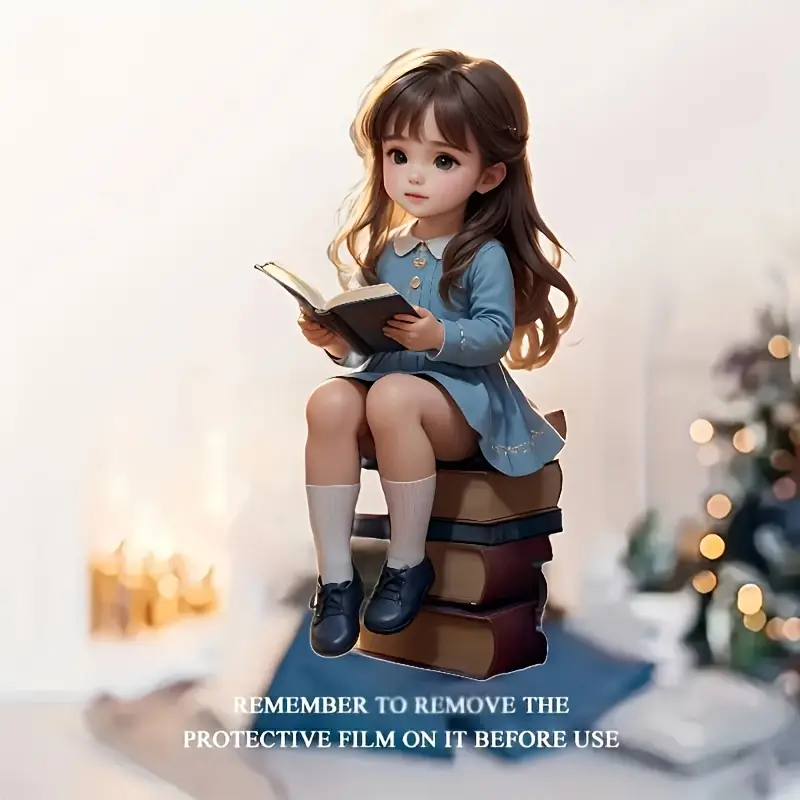

In [ ]:
from IPython.display import Image
Image("received_tcp.png")

---
### メモ
- ngrok 無料枠の TCP は毎回ランダムなポートになる。再起動するたびに③のアドレスは変わる。
- TCP トンネルにはブラウザ警告ページ（HTTP 用の interstitial）は入らないので、そのまま使える。
- 送信側が複数回・大きい画像を送っても、長さヘッダで1枚ずつ正しく区切られる（フレーミングの効果）。